# 01 — Métricas del punto focal: escalar vs. vectorial (caso base)

**Pregunta.** ¿Cuánto difiere el tamaño del lóbulo central de la intensidad
focal entre el modelo escalar y el vectorial, y cómo se deforma según la
polarización incidente?

**Reducción analítica.** Para una pupila con polarización lineal homogénea a
ángulo $\alpha$ y amplitud radial $P(r)$, la reconstrucción cartesiana de
`vecdiff` da exactamente

$$ I(\rho,\varphi) \;=\; \pi^2\left[\,|H_0|^2 + |H_2|^2
   - 2\,\mathrm{Re}(H_0 H_2^*)\cos 2(\varphi-\alpha)\,\right], $$

con $H_0 = \mathcal{H}_0[(t_p+t_s)P]$ y $H_2 = \mathcal{H}_2[(t_p-t_s)P]$.
Consecuencias que este cuaderno verifica y explota:

1. El patrón **rota rígidamente** con $\alpha$: no hay más grados de libertad
   angulares que la orientación. Basta estudiar $\alpha=0$.
2. Los **ejes principales** del lóbulo son $\varphi=\alpha$ y
   $\varphi=\alpha+90°$, con cortes $I_\parallel = \pi^2|H_0-H_2|^2$ y
   $I_\perp = \pi^2|H_0+H_2|^2$. El "radio del punto" se reemplaza por **dos
   radios principales** $(R_\parallel, R_\perp)$.
3. La incidencia **circular** da un punto simétrico
   $I_{\rm circ}\propto|H_0|^2+|H_2|^2$, que es el **promedio azimutal** del
   caso lineal.

**Referencias escalares.** Usamos dos, porque separan efectos distintos:

- *escalar apodizado*: $t_p=t_s=t_+=(t_p+t_s)/2$, es decir $t_-=0$ (sin
  mezcla de polarización pero con la apodización radial de Fresnel). Su
  perfil es $|H_0|^2$: **gratis**, ya está contenido en el caso vectorial.
- *escalar ideal*: $t_p=t_s=1$ (difracción pura de la pupila; Airy si
  $P=1$). Aísla, por comparación con el anterior, el efecto de la
  apodización $t_+(r)$.

**Convenciones.** Radios focales en unidades de $\lambda$:
$s=\rho/\lambda = q\,q_\lambda$, $q_\lambda = z_i/(2\pi n_i)$. Métricas:
HWHM (radio a mitad de intensidad central), radio del primer mínimo,
elipticidad $e=R_\perp/R_\parallel$, anisotropía
$A=(R_\perp-R_\parallel)/R_{\rm sca}$ y fracción cruzada $f_{\rm cross}$
(energía del canal $H_2$ sobre el total, en toda la banda de la pupila).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import spot_tools as st

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

## Sistema base

El mismo dioptrio estigmático de `examples/aperture_scalar_vs_vectorial.py`:
$n_0=1$, $n_i=1.5$, $z_0=-10$ mm, $z_i=6$ mm, $\lambda=532$ nm, pupila
uniforme abierta al 97% del radio de incidencia rasante.

In [2]:
case = st.spot_case(n0=1.0, ni=1.5, z0=-10.0, zi=6.0, lam=532e-6, a_frac=0.97)
s = case["s"]

print(f"radio rasante        r_graze = {case['r_graze']:.4f} mm")
print(f"apertura             a       = {case['a']:.4f} mm")
print(f"semiángulo objeto    alpha_obj = {case['alpha_obj_deg']:.1f} deg")

# Validación de la maquinaria contra el patrón de Airy (escalar ideal, P=1)
airy = st.airy_reference(case)
c = st.cuts(case)
hwhm_num = st.hwhm(s, c["ideal"])
zero_num = st.first_min_radius(s, c["ideal"])
print(f"\nAiry teórico :  HWHM = {airy['s_hwhm']:.5f} λ   primer cero = {airy['s_zero']:.5f} λ")
print(f"Airy numérico:  HWHM = {hwhm_num:.5f} λ   primer cero = {zero_num:.5f} λ")
assert abs(hwhm_num - airy["s_hwhm"]) / airy["s_hwhm"] < 1e-3
assert abs(zero_num - airy["s_zero"]) / airy["s_zero"] < 1e-2

radio rasante        r_graze = 2.3970 mm
apertura             a       = 2.3251 mm
semiángulo objeto    alpha_obj = 13.1 deg

Airy teórico :  HWHM = 0.30590 λ   primer cero = 0.72517 λ
Airy numérico:  HWHM = 0.30590 λ   primer cero = 0.72621 λ


## Mapas 2D del plano focal

Todos normalizados al valor central del escalar apodizado (que coincide con
el central vectorial, pues $H_2(0)=0$); el escalar ideal se normaliza a su
propio centro porque su transmisión es distinta.

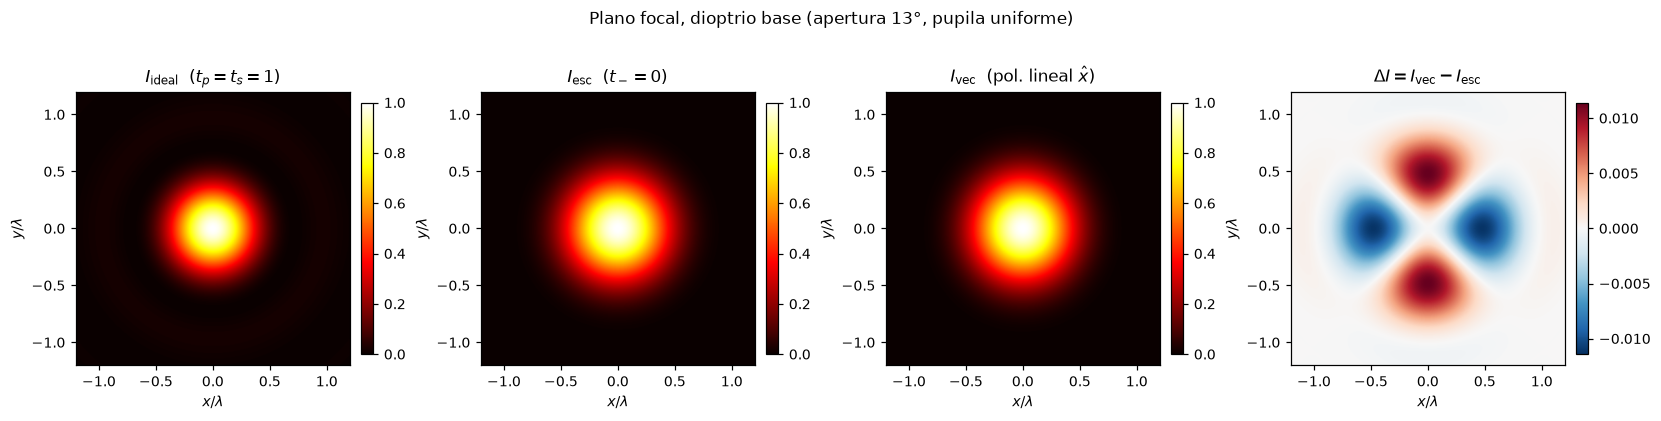

In [3]:
half_size = 1.2
maps = st.intensity_maps(case, half_size, n_img=400, alpha=0.0)
I0 = maps["I_sca"].max()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), constrained_layout=True)
panels = [
    (maps["I_ideal"] / maps["I_ideal"].max(), "hot", (0, 1), r"$I_{\rm ideal}$  ($t_p=t_s=1$)"),
    (maps["I_sca"] / I0, "hot", (0, 1), r"$I_{\rm esc}$  ($t_-=0$)"),
    (maps["I_vec"] / I0, "hot", (0, 1), r"$I_{\rm vec}$  (pol. lineal $\hat x$)"),
    ((maps["I_vec"] - maps["I_sca"]) / I0, "RdBu_r", None, r"$\Delta I = I_{\rm vec}-I_{\rm esc}$"),
]
for ax, (img, cmap, clim, title) in zip(axes, panels):
    vmax = np.abs(img).max()
    kw = dict(vmin=-vmax, vmax=vmax) if clim is None else dict(vmin=clim[0], vmax=clim[1])
    im = ax.imshow(img, extent=maps["extent"], origin="lower", cmap=cmap, **kw)
    ax.set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Plano focal, dioptrio base (apertura {case['alpha_obj_deg']:.0f}°, pupila uniforme)")
fig.savefig(out_dir / "01_focal_maps.png", dpi=200)
plt.show()

El mapa $\Delta I$ muestra el patrón cuadrupolar $\cos 2\varphi$: el campo
vectorial *quita* intensidad del flanco del lóbulo a lo largo de la
polarización y la *agrega* en la dirección ortogonal.

## Radios medidos, anotados sobre los mapas (dioptrio rápido)

Cada mapa lleva superpuestos el contorno HWHM **medido** (blanco), el radio
escalar de referencia (cian, a trazos) y los radios principales con sus
valores; la ventana muestra a lo sumo tres máximos secundarios.

En el dioptrio base de vidrio la deformación es pequeña ($e\approx1.05$):
el vidrio la limita a $e\lesssim1.08$ aun a apertura rasante (el índice fija
el techo — cuaderno 02). Para que la diferencia vectorial–escalar sea
evidente se anota aquí un **dioptrio rápido de alto índice**: $n_i=2.4$,
$z_0=-2$ mm, $z_i=6$ mm, apertura al 97 % del rasante
($\alpha_{\rm obj}\approx57°$, NA de imagen en el medio
$n_i\sin\alpha_{\rm img}\approx1.1$). A la izquierda, polarización lineal a
$\alpha=20°$ (la elipse rota rígidamente con $\alpha$); a la derecha,
incidencia circular (punto simétrico).

α_obj = 51.2°,  NA_img (en el medio) = 0.92


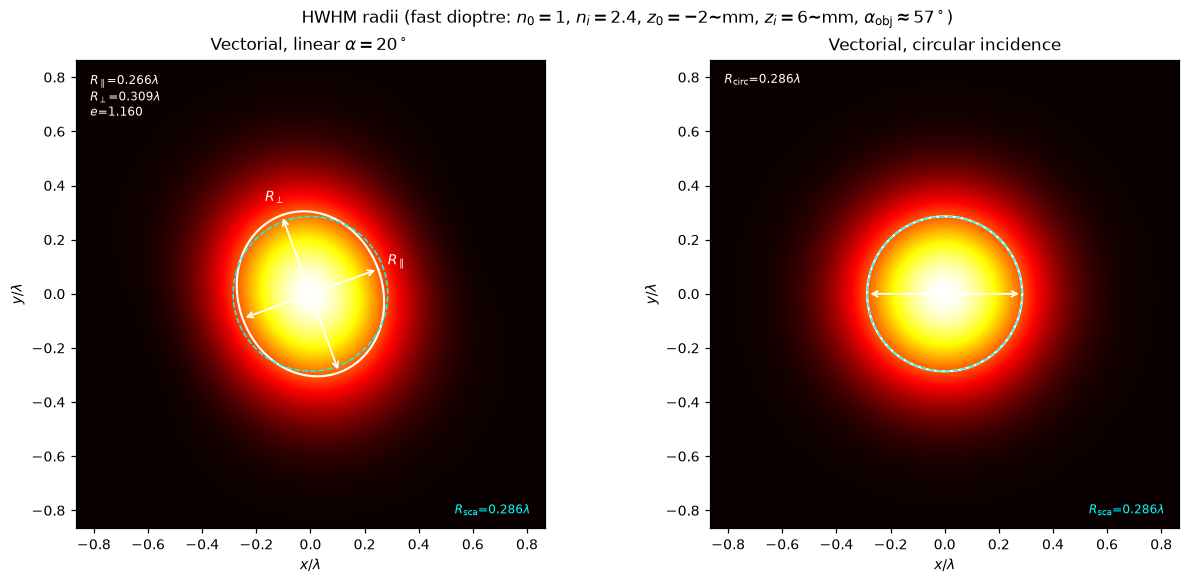

lineal  : R∥ = 0.2664 λ,  R⊥ = 0.3091 λ,  e = 1.1605
circular: R  = 0.2862 λ  (escalar: 0.2856 λ)
dioptrio base (vidrio, α_obj=20°): e = 1.0281


In [4]:
case_hna = st.spot_case(n0=1.0, ni=2.4, z0=-2.0, zi=6.0, lam=532e-6, a_frac=0.97)
print(f"α_obj = {case_hna['alpha_obj_deg']:.1f}°,  "
      f"NA_img (en el medio) = {case_hna['ni'] * np.sin(np.arctan(case_hna['a'] / case_hna['zi'])):.2f}")

fig, axs = plt.subplots(1, 2, figsize=(11.5, 5.2), constrained_layout=True)
_, m_lin = st.plot_spot_with_radii(axs[0], case_hna, alpha=np.deg2rad(20), incidence="linear")
axs[0].set_title(r"Vectorial, linear $\alpha=20^\circ$")
_, m_cir = st.plot_spot_with_radii(axs[1], case_hna, incidence="circular")
axs[1].set_title("Vectorial, circular incidence")
fig.suptitle(r"HWHM radii (fast dioptre: $n_0=1$, $n_i=2.4$, $z_0=-2$~mm, $z_i=6$~mm, $\alpha_{\rm obj}\approx57^\circ$)")
fig.savefig(out_dir / "01_annotated_spots.png", dpi=200)
plt.show()

print(f"lineal  : R∥ = {m_lin['R_par']:.4f} λ,  R⊥ = {m_lin['R_perp']:.4f} λ,  e = {m_lin['ellipticity']:.4f}")
print(f"circular: R  = {m_cir['R_circ']:.4f} λ  (escalar: {m_cir['R_sca']:.4f} λ)")
print(f"dioptrio base (vidrio, α_obj=20°): e = {st.spot_metrics(case)['ellipticity']:.4f}")

## Cortes principales y métricas

/tmp/ipykernel_8633/705385080.py:1: RuntimeWarning: divide by zero encountered in divide
  norm = {k: v / v[0] for k, v in c.items()}
/tmp/ipykernel_8633/705385080.py:1: RuntimeWarning: invalid value encountered in divide
  norm = {k: v / v[0] for k, v in c.items()}


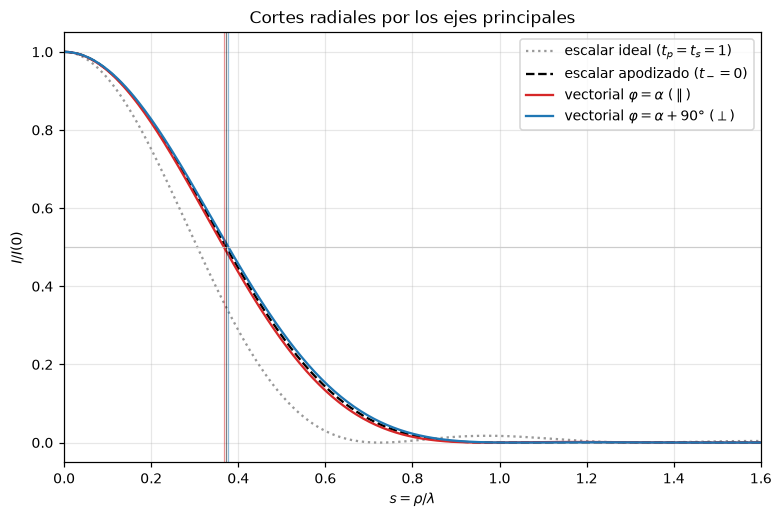

campo                    HWHM [λ]  1er mín [λ]
escalar ideal              0.3059       0.7262
escalar apodizado          0.3722       1.0017
vectorial ∥                0.3671       0.9716
vectorial ⊥                0.3774       1.0317
circular                   0.3722       1.0017

elipticidad  e = R_perp/R_par     = 1.0281
anisotropía  A = (R⊥-R∥)/R_sca    = 0.0277
fracción cruzada f_cross          = 0.00108


In [5]:
norm = {k: v / v[0] for k, v in c.items()}

fig, ax = plt.subplots(figsize=(7, 4.6), constrained_layout=True)
ax.plot(s, norm["ideal"], color="0.6", ls=":", label=r"escalar ideal ($t_p=t_s=1$)")
ax.plot(s, norm["sca"], "k--", label=r"escalar apodizado ($t_-=0$)")
ax.plot(s, norm["par"], "C3", label=r"vectorial $\varphi=\alpha$ ($\parallel$)")
ax.plot(s, norm["perp"], "C0", label=r"vectorial $\varphi=\alpha+90°$ ($\perp$)")
ax.axhline(0.5, color="0.8", lw=0.8)
m = st.spot_metrics(case)
for R, color in [(m["R_par"], "C3"), (m["R_perp"], "C0"), (m["R_sca"], "k")]:
    ax.axvline(R, color=color, lw=0.8, alpha=0.5)
ax.set(xlim=(0, 1.6), xlabel=r"$s=\rho/\lambda$", ylabel=r"$I/I(0)$",
       title="Cortes radiales por los ejes principales")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(out_dir / "01_principal_cuts.png", dpi=200)
plt.show()

print(f"{'campo':22s} {'HWHM [λ]':>10s} {'1er mín [λ]':>12s}")
for name, label in [("ideal", "escalar ideal"), ("sca", "escalar apodizado"),
                    ("par", "vectorial ∥"), ("perp", "vectorial ⊥"), ("circ", "circular")]:
    print(f"{label:22s} {st.hwhm(s, c[name]):10.4f} {st.first_min_radius(s, c[name]):12.4f}")
print(f"\nelipticidad  e = R_perp/R_par     = {m['ellipticity']:.4f}")
print(f"anisotropía  A = (R⊥-R∥)/R_sca    = {m['anisotropy']:.4f}")
print(f"fracción cruzada f_cross          = {m['f_cross']:.5f}")

Dos observaciones centrales:

- $R_\parallel < R_{\rm sca} < R_\perp$: respecto del escalar, el punto
  vectorial se **contrae a lo largo de la polarización** y se **expande en
  la ortogonal** (el término $-2\,\mathrm{Re}(H_0H_2^*)\cos2\varphi$ es
  negativo en $\varphi=0$ porque $H_0H_2^*>0$ cerca del eje).
- La apodización de Fresnel $t_+(r)$ (que decae hacia el borde) ensancha el
  punto respecto del escalar ideal **mucho más** de lo que la mezcla
  vectorial lo deforma, a esta apertura.

## Frontera del lóbulo: $R_{\rm HWHM}(\psi)$

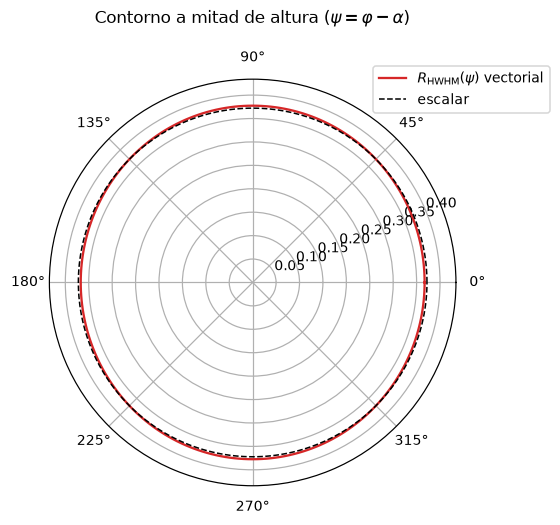

R(ψ) mín = 0.3671 λ (en ψ=0, π)   R(ψ) máx = 0.3774 λ (en ψ=±π/2)


In [6]:
psi, radii = st.hwhm_vs_psi(case, n_psi=241)

fig, ax = plt.subplots(subplot_kw={"projection": "polar"}, figsize=(4.8, 4.8))
ax.plot(psi, radii, "C3", label=r"$R_{\rm HWHM}(\psi)$ vectorial")
ax.plot(psi, np.full_like(psi, m["R_sca"]), "k--", lw=1, label="escalar")
ax.set_title(r"Contorno a mitad de altura ($\psi=\varphi-\alpha$)", pad=18)
ax.set_rlim(0, 1.15 * radii.max())
ax.legend(loc="lower left", bbox_to_anchor=(0.78, 0.9))
fig.savefig(out_dir / "01_hwhm_contour.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"R(ψ) mín = {radii.min():.4f} λ (en ψ=0, π)   R(ψ) máx = {radii.max():.4f} λ (en ψ=±π/2)")

## Verificación: el patrón rota rígidamente con $\alpha$

La fórmula reducida se contrasta con la tubería completa del paquete
(`hankel_terms` + `reconstruct_2d_from_terms`) para $\alpha=30°$:
$e_1=\cos\alpha\,P$, $e_2=\sin\alpha\,P$.

rayo φ=  0.0°:  máx |I_tubería - I_fórmula| / I(0) = 8.34e-16
rayo φ= 17.0°:  máx |I_tubería - I_fórmula| / I(0) = 7.30e-16
rayo φ= 45.0°:  máx |I_tubería - I_fórmula| / I(0) = 8.34e-16
rayo φ= 90.0°:  máx |I_tubería - I_fórmula| / I(0) = 8.34e-16
rayo φ=133.0°:  máx |I_tubería - I_fórmula| / I(0) = 1.04e-15

mapas 2D interpolados: máx dif = 1.41e-05 (limitada por interpolación)


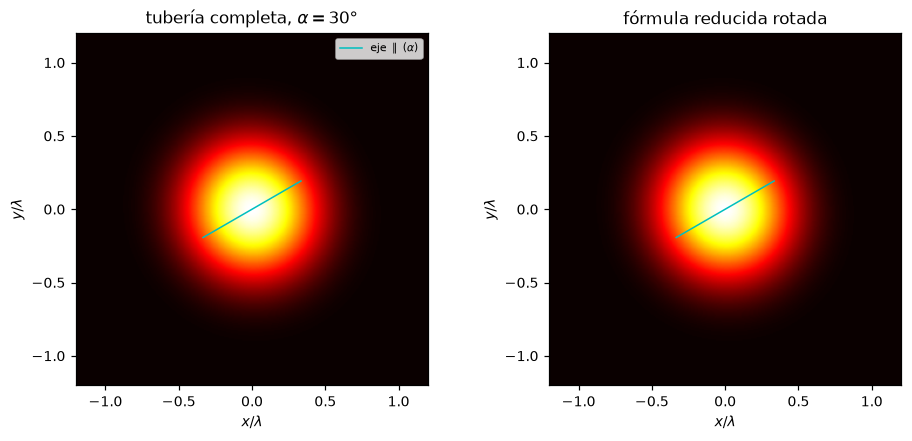

In [7]:
from vecdiff.field_reconstruction import hankel_terms, reconstruct_2d_from_terms, make_observation_grid

alpha = np.radians(30.0)
terms = hankel_terms(case["u"], case["q"], case["tp"], case["ts"],
                     e1=np.cos(alpha) * case["P"], e2=np.sin(alpha) * case["P"],
                     polarization="cartesian")

# Rayos evaluados en los nodos radiales exactos: la comparación es exacta
# (sin error de interpolación).
for phi_deg in (0.0, 17.0, 45.0, 90.0, 133.0):
    phi0 = np.radians(phi_deg)
    Ex_r, Ey_r = reconstruct_2d_from_terms(terms, s, s, np.full_like(s, phi0),
                                           polarization="cartesian")
    I_ray = (np.abs(Ex_r) ** 2 + np.abs(Ey_r) ** 2) / np.pi ** 2
    I_form = st.intensity_cut(case, phi0 - alpha)
    rel = np.max(np.abs(I_ray - I_form)) / I_form[0]
    print(f"rayo φ={phi_deg:5.1f}°:  máx |I_tubería - I_fórmula| / I(0) = {rel:.2e}")
    assert rel < 1e-10

# Mapas 2D: aquí la tubería interpola H(s) y la fórmula interpola |H|²(s),
# ambas linealmente, así que difieren en O(Δs²) — no es física, es interpolación.
xx, yy, rho, varphi, extent = make_observation_grid(half_size, 300)
Ex, Ey = reconstruct_2d_from_terms(terms, s, rho, varphi, polarization="cartesian")
I_pipe = np.abs(Ex) ** 2 + np.abs(Ey) ** 2
I_pipe /= I_pipe.max()

I_formula = st.intensity_maps(case, half_size, n_img=300, alpha=alpha)["I_vec"]
I_formula /= I_formula.max()
print(f"\nmapas 2D interpolados: máx dif = {np.max(np.abs(I_pipe - I_formula)):.2e} (limitada por interpolación)")

fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.9), constrained_layout=True)
for ax, img, title in [(axes[0], I_pipe, r"tubería completa, $\alpha=30°$"),
                       (axes[1], I_formula, "fórmula reducida rotada")]:
    ax.imshow(img, extent=extent, origin="lower", cmap="hot")
    L = 1.05 * m["R_par"]
    ax.plot([-L * np.cos(alpha), L * np.cos(alpha)], [-L * np.sin(alpha), L * np.sin(alpha)],
            "c-", lw=1, label=r"eje $\parallel$ ($\alpha$)")
    ax.set(title=title, xlabel=r"$x/\lambda$", ylabel=r"$y/\lambda$")
axes[0].legend(loc="upper right", fontsize=7)
fig.savefig(out_dir / "01_rigid_rotation.png", dpi=200)
plt.show()

La coincidencia es a precisión de máquina: **la orientación $\alpha$ no
introduce física nueva**; los dos radios principales siguen a la
polarización. Todo barrido paramétrico puede hacerse con $\alpha=0$.

## Incidencia circular

$I_{\rm circ}\propto |H_0|^2+|H_2|^2$: simétrico, igual al promedio azimutal
del caso lineal. El canal cruzado no deforma el punto, solo lo ensancha
(suma un anillo $|H_2|^2$ nulo en el eje).

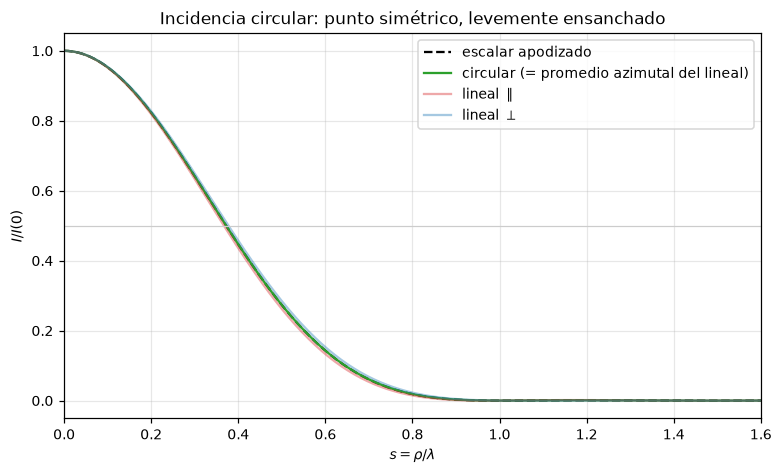

R_circ (HWHM) = 0.3722 λ   vs   R_sca = 0.3722 λ
radio de energía encerrada 50% (ventana s<3.0λ): circ 0.3523 λ, esc 0.3521 λ


In [8]:
fig, ax = plt.subplots(figsize=(7, 4.2), constrained_layout=True)
ax.plot(s, norm["sca"], "k--", label="escalar apodizado")
ax.plot(s, norm["circ"], "C2", label="circular (= promedio azimutal del lineal)")
ax.plot(s, norm["par"], "C3", alpha=0.4, label=r"lineal $\parallel$")
ax.plot(s, norm["perp"], "C0", alpha=0.4, label=r"lineal $\perp$")
ax.axhline(0.5, color="0.8", lw=0.8)
ax.set(xlim=(0, 1.6), xlabel=r"$s=\rho/\lambda$", ylabel=r"$I/I(0)$",
       title="Incidencia circular: punto simétrico, levemente ensanchado")
ax.grid(alpha=0.3)
ax.legend()
fig.savefig(out_dir / "01_circular_incidence.png", dpi=200)
plt.show()

ee_sca = st.encircled_radius(s, c["sca"], 0.5)
ee_circ = st.encircled_radius(s, c["circ"], 0.5)
print(f"R_circ (HWHM) = {m['R_circ']:.4f} λ   vs   R_sca = {m['R_sca']:.4f} λ")
print(f"radio de energía encerrada 50% (ventana s<{s[-1]:.1f}λ): circ {ee_circ:.4f} λ, esc {ee_sca:.4f} λ")

## Adelanto: dependencia con la apertura

Barrido rápido de la apertura (pupila uniforme, mismo dioptrio). El estudio
amplio (índice, forma de pupila) es el cuaderno 03.

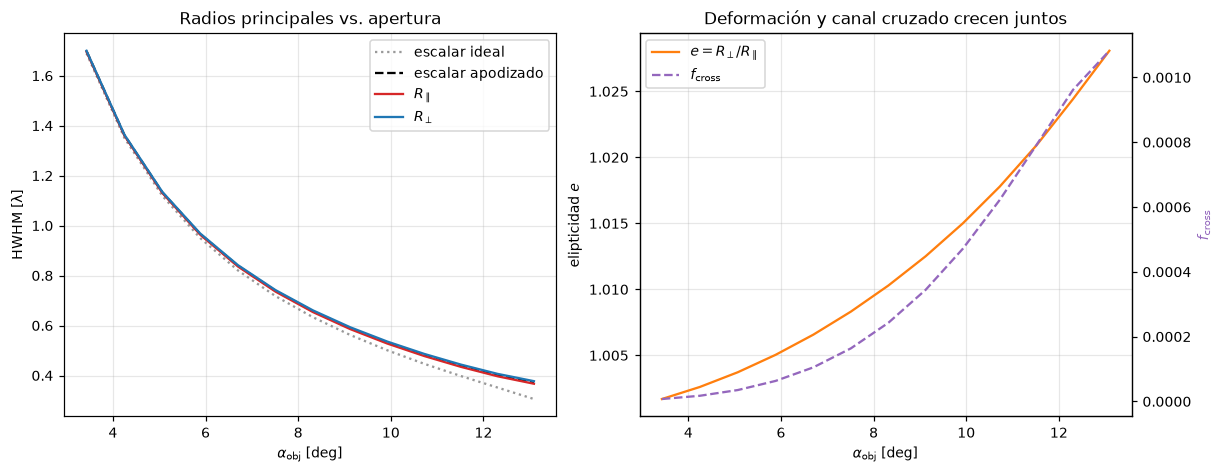

In [9]:
fracs = np.linspace(0.25, 0.97, 13)
scan = [st.spot_metrics(st.spot_case(a_frac=f, n_r=600, n_q=400)) for f in fracs]
alphas = [st.spot_case(a_frac=f, n_r=8, n_q=2)["alpha_obj_deg"] for f in fracs]
get = lambda k: np.array([mm[k] for mm in scan])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
axes[0].plot(alphas, get("R_ideal"), color="0.6", ls=":", label="escalar ideal")
axes[0].plot(alphas, get("R_sca"), "k--", label="escalar apodizado")
axes[0].plot(alphas, get("R_par"), "C3", label=r"$R_\parallel$")
axes[0].plot(alphas, get("R_perp"), "C0", label=r"$R_\perp$")
axes[0].set(xlabel=r"$\alpha_{\rm obj}$ [deg]", ylabel="HWHM [λ]", title="Radios principales vs. apertura")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(alphas, get("ellipticity"), "C1", label=r"$e=R_\perp/R_\parallel$")
ax2 = axes[1].twinx()
ax2.plot(alphas, get("f_cross"), "C4--", label=r"$f_{\rm cross}$")
ax2.set_ylabel(r"$f_{\rm cross}$", color="C4")
axes[1].set(xlabel=r"$\alpha_{\rm obj}$ [deg]", ylabel=r"elipticidad $e$",
            title="Deformación y canal cruzado crecen juntos")
axes[1].grid(alpha=0.3)
h1, l1 = axes[1].get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
axes[1].legend(h1 + h2, l1 + l2, loc="upper left")
fig.savefig(out_dir / "01_aperture_teaser.png", dpi=200)
plt.show()

## Conclusiones del caso base

1. La reducción $I=\pi^2[|H_0|^2+|H_2|^2-2\,\mathrm{Re}(H_0H_2^*)\cos2(\varphi-\alpha)]$
   está verificada contra la tubería completa a precisión de máquina, y el
   patrón rota rígidamente con $\alpha$: dos radios principales
   $(R_\parallel, R_\perp)$ describen el lóbulo central del caso lineal.
2. A apertura alta del dioptrio de vidrio ($\alpha_{\rm obj}=20°$):
   contracción $\sim 2.6\%$ a lo largo de la polarización y expansión
   $\sim 2.8\%$ en la ortogonal (e ≈ 1.055), con $f_{\rm cross}\sim 0.4\%$.
3. La apodización $t_+(r)$ ensancha el punto (vs. Airy ideal) mucho más de lo
   que la mezcla vectorial lo deforma: al comparar "escalar vs. vectorial"
   hay que declarar cuál referencia escalar se usa.
4. Con incidencia circular el punto queda simétrico e igual al promedio
   azimutal del lineal: el canal cruzado solo ensancha.

**Siguiente:** `02_cross_maximization` (qué maximiza el canal $H_2$) y
`03_deformation_vs_cross` (deformación vs. $f_{\rm cross}$ en barridos
amplios de apertura, índice y pupila).